# 🚀 End-to-End Credit Risk Prediction: Random Forest vs XGBoost

Welcome! In the financial industry, accurately assessing credit risk is crucial for minimizing bad loans and maximizing profitability. 

This notebook demonstrates a complete, end-to-end data science workflow to solve a real-world business problem: predicting whether a loan applicant should be approved or rejected based on their financial and demographic profiles.

### 🔍 Project Highlights:
* **Data Cleaning & Preprocessing:** Handling missing values, encoding categorical variables, and preparing raw data for machine learning.
* **Predictive Modeling:** Training and comparing two of the most powerful ensemble algorithms in the industry: **Random Forest** and **XGBoost**.
* **Performance Evaluation:** Analyzing model accuracy (both achieved >96% accuracy) and extracting Feature Importance to understand the key drivers behind credit decisions.

### 📊 Interactive Business Dashboard
Data science is not just about writing code; it's about delivering actionable business insights. I have transformed the models' predictions into a dynamic, business-ready dashboard. 

👉 **[Click Here to Explore the Interactive Looker Studio Dashboard](https://datastudio.google.com/reporting/68470220-8d17-4183-9865-240769cc3c01)**

---
*Feel free to explore the code, fork this notebook, or connect with me for feedback and collaboration opportunities. Let's dive into the data!* 💡

In [1]:
import pandas as pd

# Paste alamat file yang baru saja Anda salin ke dalam tanda kutip ini
file_path_risk = '/kaggle/input/datasets/hanggersukmapd/data-clean-before-2/loan_risk_prediction_dataset.csv' 

# Kita gunakan nama variabel df_risk agar membedakan dari dataset sebelumnya
df_risk = pd.read_csv(file_path_risk)

# Menampilkan 5 data teratas
display(df_risk.head())

# Mengecek tipe data dan data kosong
df_risk.info()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [2]:
# 1. Cek dan hapus data duplikat (jika ada)
jumlah_duplikat = df_risk.duplicated().sum()
print(f"Jumlah baris duplikat awal: {jumlah_duplikat}")
df_risk = df_risk.drop_duplicates()

# 2. Mengisi data kosong pada kolom angka (Numerik) dengan Median
df_risk['Income'] = df_risk['Income'].fillna(df_risk['Income'].median())
df_risk['CreditScore'] = df_risk['CreditScore'].fillna(df_risk['CreditScore'].median())

# 3. Mengisi data kosong pada kolom teks (Kategorik) dengan Modus
modus_education = df_risk['Education'].mode()[0]
df_risk['Education'] = df_risk['Education'].fillna(modus_education)

# 4. Mengecek kembali kesehatan data setelah dibersihkan
print("\nKondisi data setelah proses imputasi:")
df_risk.info()

Jumlah baris duplikat awal: 0

Kondisi data setelah proses imputasi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           5000 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      5000 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        5000 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [3]:
# Mencari semua kolom bertipe data teks ('object')
kolom_teks_risk = df_risk.select_dtypes(include=['object']).columns

# Menampilkan nilai unik dari masing-masing kolom teks
for kolom in kolom_teks_risk:
    print(f"Variasi isi di kolom {kolom}: {df_risk[kolom].unique()}")

Variasi isi di kolom Gender: ['Female' 'Male']
Variasi isi di kolom Education: ['High School' 'PhD' 'Bachelors' 'Masters']
Variasi isi di kolom City: ['Houston' 'San Francisco' 'New York' 'Chicago']
Variasi isi di kolom EmploymentType: ['Unemployed' 'Self-Employed' 'Salaried']


In [4]:
# 1. Membuat kamus terjemahan untuk data Ordinal dan Biner
pemetaan_gender = {'Female': 0, 'Male': 1}
pemetaan_edu = {'High School': 0, 'Bachelors': 1, 'Masters': 2, 'PhD': 3}
pemetaan_kerja = {'Unemployed': 0, 'Self-Employed': 1, 'Salaried': 2}

# 2. Menerapkan terjemahan ke kolom masing-masing
df_risk['Gender'] = df_risk['Gender'].map(pemetaan_gender)
df_risk['Education'] = df_risk['Education'].map(pemetaan_edu)
df_risk['EmploymentType'] = df_risk['EmploymentType'].map(pemetaan_kerja)

# 3. Menerapkan One-Hot Encoding untuk kolom 'City'
# drop_first=True digunakan agar tidak ada redundansi (jika bukan Houston, SF, atau NY, pasti Chicago)
df_risk = pd.get_dummies(df_risk, columns=['City'], drop_first=True, dtype=int)

# 4. Menampilkan hasil akhir dan tipe data
print("\nTipe data semua kolom saat ini:")
print(df_risk.dtypes)
display(df_risk.head())


Tipe data semua kolom saat ini:
Age                     int64
Income                float64
LoanAmount            float64
CreditScore           float64
YearsExperience         int64
Gender                  int64
Education               int64
EmploymentType          int64
LoanApproved            int64
City_Houston            int64
City_New York           int64
City_San Francisco      int64
dtype: object


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,EmploymentType,LoanApproved,City_Houston,City_New York,City_San Francisco
0,56,48353.0,31258.0,675.0,20,0,0,0,0,1,0,0
1,69,57462.0,23262.0,586.0,6,1,0,1,0,0,0,1
2,46,44219.0,26530.0,781.0,26,1,3,1,1,1,0,0
3,32,56307.0,11531.0,549.0,11,1,1,0,0,0,1,0
4,60,37034.0,27871.0,500.0,19,0,0,0,0,0,0,0


In [5]:
# Menyimpan DataFrame kedua menjadi file CSV bersih
df_risk.to_csv('clean_credit_risk_dataset.csv', index=False)

print("Dataset Credit Risk berhasil dibersihkan dan disimpan!")

Dataset Credit Risk berhasil dibersihkan dan disimpan!


In [6]:
# Memanggil library khusus Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. Memisahkan Fitur (X) dan Target/Label (y)
# Target kita adalah kolom 'LoanApproved' (0 = Ditolak, 1 = Diterima)
X = df_risk.drop('LoanApproved', axis=1)
y = df_risk['LoanApproved']

# 2. Membagi Data: 80% untuk Belajar (Train) dan 20% untuk Ujian (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Menyiapkan Kedua "Otak" Algoritma
model_rf = RandomForestClassifier(random_state=42)
model_xgb = XGBClassifier(random_state=42, eval_metric='logloss')

# 4. Menyuruh Algoritma Belajar dari Data Latih
model_rf.fit(X_train, y_train)
model_xgb.fit(X_train, y_train)

# 5. Menyuruh Algoritma Mengerjakan Soal Ujian (Memprediksi Data Uji)
prediksi_rf = model_rf.predict(X_test)
prediksi_xgb = model_xgb.predict(X_test)

# 6. Memeriksa Nilai Ujian (Akurasi)
akurasi_rf = accuracy_score(y_test, prediksi_rf)
akurasi_xgb = accuracy_score(y_test, prediksi_xgb)

print("=== HASIL PERBANDINGAN PERFORMA ===")
print(f"Akurasi Random Forest : {akurasi_rf * 100:.2f}%")
print(f"Akurasi XGBoost       : {akurasi_xgb * 100:.2f}%")

=== HASIL PERBANDINGAN PERFORMA ===
Akurasi Random Forest : 96.50%
Akurasi XGBoost       : 96.30%


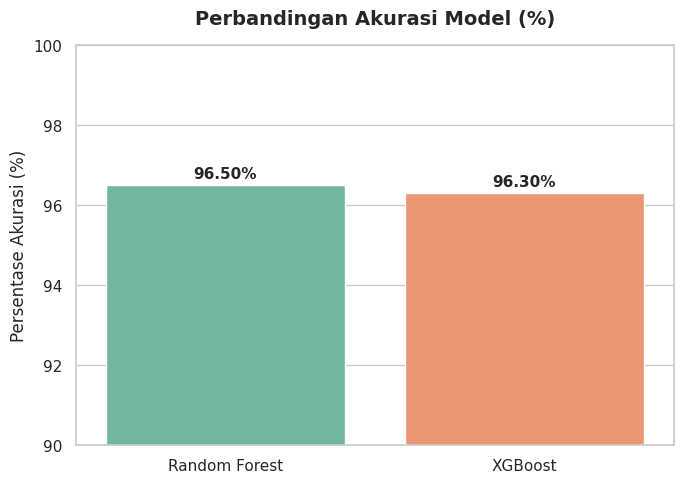

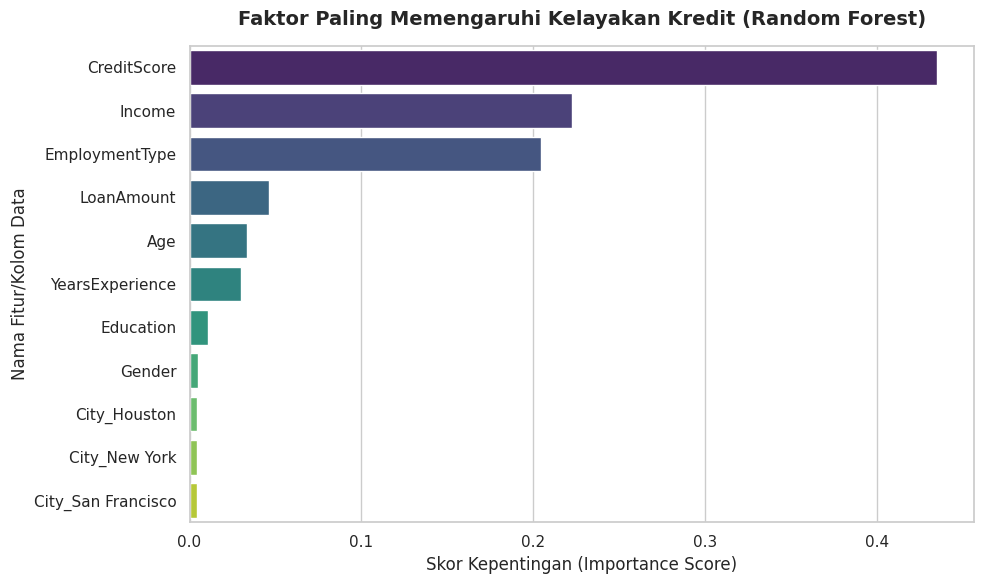

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set tema grafik
sns.set_theme(style="whitegrid")

# ==========================================
# GRAFIK 1: PERBANDINGAN AKURASI MODEL
# ==========================================
plt.figure(figsize=(7, 5))
model_names = ['Random Forest', 'XGBoost']
skor_akurasi = [akurasi_rf * 100, akurasi_xgb * 100]

# Menambahkan hue=model_names dan legend=False untuk menghilangkan FutureWarning
ax = sns.barplot(x=model_names, y=skor_akurasi, hue=model_names, palette='Set2', legend=False)

plt.ylim(90, 100) 
plt.title('Perbandingan Akurasi Model (%)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Persentase Akurasi (%)', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# GRAFIK 2: FAKTOR PALING BERPENGARUH (FEATURE IMPORTANCE)
# ==========================================
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]
fitur_diurutkan = X.columns[indices]
nilai_diurutkan = importances[indices]

plt.figure(figsize=(10, 6))

# Menambahkan hue=fitur_diurutkan dan legend=False agar FutureWarning hilang
sns.barplot(x=nilai_diurutkan, y=fitur_diurutkan, hue=fitur_diurutkan, palette='viridis', legend=False)

plt.title('Faktor Paling Memengaruhi Kelayakan Kredit (Random Forest)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Skor Kepentingan (Importance Score)', fontsize=12)
plt.ylabel('Nama Fitur/Kolom Data', fontsize=12)

plt.tight_layout()
plt.show()

In [8]:
# 1. Membuat DataFrame baru dari data ujian (X_test)
df_hasil_prediksi = X_test.copy()

# 2. Memasukkan jawaban asli dan hasil tebakan dengan NAMA KOLOM BAHASA INGGRIS
df_hasil_prediksi['Actual Data'] = y_test
df_hasil_prediksi['Random Forest Predictions'] = prediksi_rf
df_hasil_prediksi['XGBoost Predictions'] = prediksi_xgb

# 3. MENGUBAH ISI DATA MENJADI BAHASA INGGRIS
# Catatan: Asumsi 1 adalah Approved, dan 0 adalah Rejected.
# Jika data asli Anda berupa teks, ganti pemetaan menjadi: {'Diterima': 'Approved', 'Ditolak': 'Rejected'}
pemetaan_status = {1: 'Approved', 0: 'Rejected'}

# Menerapkan pemetaan ke ketiga kolom tersebut
kolom_target = ['Actual Data', 'Random Forest Predictions', 'XGBoost Predictions']
for kolom in kolom_target:
    df_hasil_prediksi[kolom] = df_hasil_prediksi[kolom].replace(pemetaan_status)

# 4. Menyimpan menjadi file CSV khusus untuk Looker Studio
df_hasil_prediksi.to_csv('credit_risk_predictions_english.csv', index=False)

print("File 'credit_risk_predictions_english.csv' berhasil dibuat dengan format bahasa Inggris!")
display(df_hasil_prediksi.head())

File 'credit_risk_predictions_english.csv' berhasil dibuat dengan format bahasa Inggris!


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,EmploymentType,City_Houston,City_New York,City_San Francisco,Actual Data,Random Forest Predictions,XGBoost Predictions
1501,59,47802.0,24574.0,660.0,36,1,3,1,1,0,0,Approved,Approved,Approved
2586,25,49488.0,11742.0,723.0,26,1,0,2,1,0,0,Approved,Approved,Approved
2653,38,20215.0,15629.0,494.0,31,1,0,1,0,1,0,Rejected,Rejected,Rejected
1055,48,51531.0,31439.0,809.0,21,1,3,2,0,0,0,Approved,Approved,Approved
705,53,55114.0,10732.0,370.0,19,1,3,1,1,0,0,Rejected,Rejected,Rejected
